In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
data = {
    "income": [25000, 45000, 60000, 30000, 80000, 55000, 20000, 90000, 70000, 35000,
               65000, 28000, 75000, 50000, 40000, 85000, 22000, 95000, 58000, 32000],

    "debt": [15000, 10000, 5000, 18000, 8000, 7000, 16000, 4000, 6000, 12000,
             5000, 14000, 7000, 6000, 11000, 3000, 17000, 2000, 7000, 13000],

    "payment_history": [60, 85, 95, 50, 90, 88, 45, 98, 92, 70,
                         94, 55, 96, 86, 65, 97, 40, 99, 89, 60],

    "creditworthy": [0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
                     1, 0, 1, 1, 0, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)

df.head()

,income,debt,payment_history,creditworthy
0,25000,15000,60,0
1,45000,10000,85,1
2,60000,5000,95,1
3,30000,18000,50,0
4,80000,8000,90,1


In [3]:
X = df[["income", "debt", "payment_history"]]
y = df["creditworthy"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


In [9]:
new_customer = [[60000, 7000, 90]]

new_customer_scaled = scaler.transform(new_customer)

prediction = model.predict(new_customer_scaled)

if prediction[0] == 1:
    print("Creditworthy")
else:
    print("Not Creditworthy")

Creditworthy


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [10]:
import pandas as pd

df = pd.read_csv("german.data", sep=" ", header=None)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 21)


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [13]:
columns = [
    "checking_status",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_status",
    "employment",
    "installment_rate",
    "personal_status",
    "other_parties",
    "residence_since",
    "property_magnitude",
    "age",
    "other_payment_plans",
    "housing",
    "existing_credits",
    "job",
    "num_dependents",
    "own_telephone",
    "foreign_worker",
    "credit_risk"
]

df.columns = columns

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [14]:
print("Dataset shape:", df.shape)
print("\nCredit Risk:")
print(df["credit_risk"].value_counts())

Dataset shape: (1000, 21)

Credit Risk:
credit_risk
1    700
2    300
Name: count, dtype: int64


In [15]:
# Convert credit risk
# 1 = Good credit → 1
# 2 = Bad credit → 0

df["credit_risk"] = df["credit_risk"].map({1: 1, 2: 0})

print(df["credit_risk"].value_counts())

credit_risk
1    700
0    300
Name: count, dtype: int64


In [16]:
X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1000, 20)
Target: (1000,)


In [17]:
print(X.dtypes)

checking_status        object
duration                int64
credit_history         object
purpose                object
credit_amount           int64
savings_status         object
employment             object
installment_rate        int64
personal_status        object
other_parties          object
residence_since         int64
property_magnitude     object
age                     int64
other_payment_plans    object
housing                object
existing_credits        int64
job                    object
num_dependents          int64
own_telephone          object
foreign_worker         object
dtype: object


In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_columns = X.select_dtypes(include=["object"]).columns
numerical_columns = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("numerical", "passthrough", numerical_columns)
    ]
)

X_processed = preprocessor.fit_transform(X)

print("Original features:", X.shape)
print("Processed features:", X_processed.shape)

Original features: (1000, 20)
Processed features: (1000, 61)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 61)
Testing data: (200, 61)


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions completed!")

Predictions completed!


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation")
print("-----------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Model Evaluation
-----------------
Accuracy : 0.715
Precision: 0.7823
Recall   : 0.8214
F1 Score : 0.8014
ROC-AUC  : 0.7561


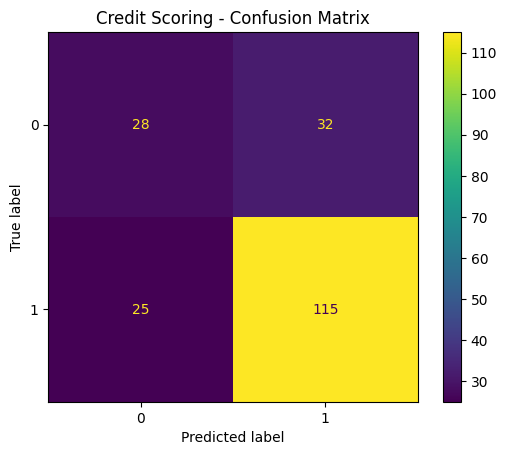

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Credit Scoring - Confusion Matrix")
plt.show()

In [24]:
new_customer = X.iloc[[0]]

new_customer_processed = preprocessor.transform(new_customer)

prediction = model.predict(new_customer_processed)

if prediction[0] == 1:
    print("Prediction: Good Credit")
else:
    print("Prediction: Bad Credit")

Prediction: Good Credit


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))

Accuracy : 0.715
Precision: 0.7823
Recall   : 0.8214
F1 Score : 0.8014
ROC-AUC  : 0.7561
